In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the original Excel file
file_path = 'knowledgeanalysis.xlsx'  # Replace with the actual path
data = pd.read_excel(file_path, sheet_name='Sheet2')


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/opt/anaconda3/lib/python3.7/site-packages/pandas/core/frame.py:5182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downcast=downcast,


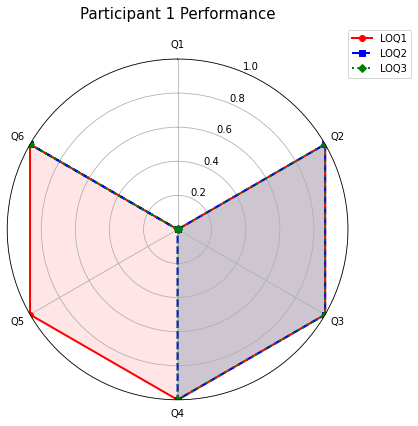

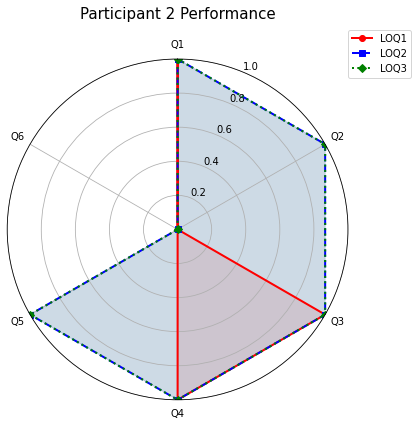

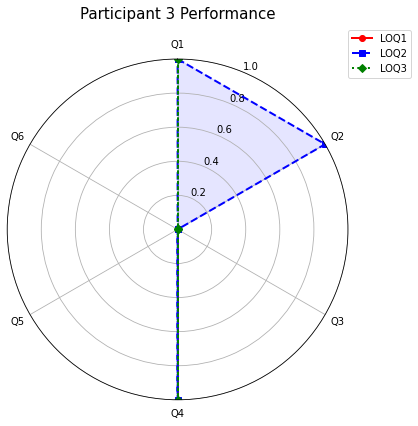

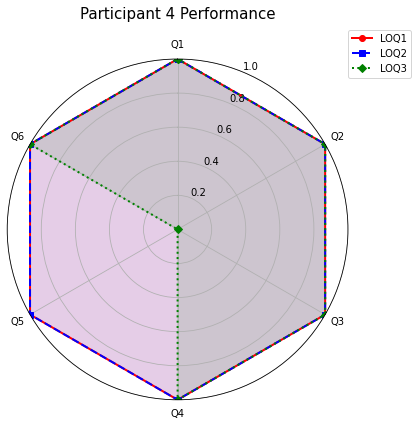

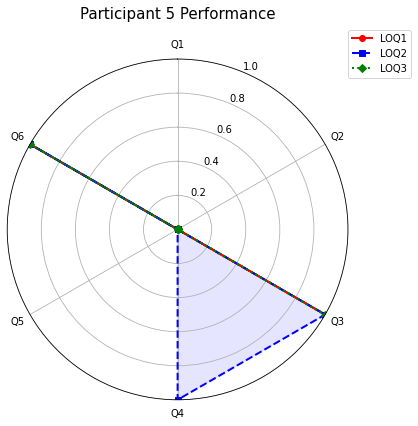

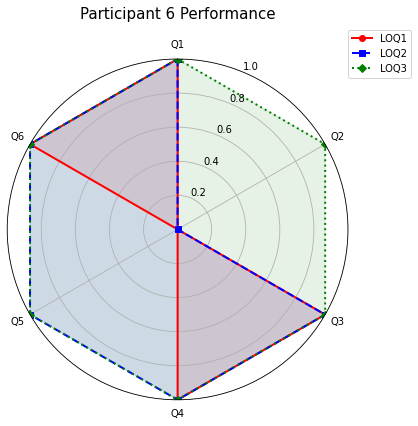

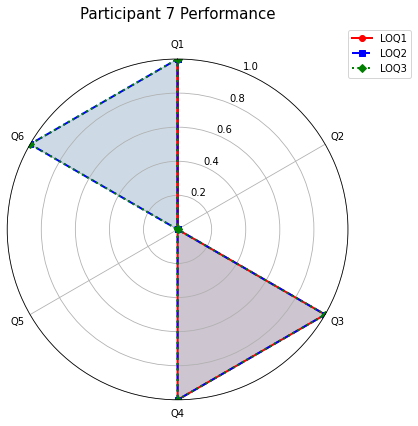

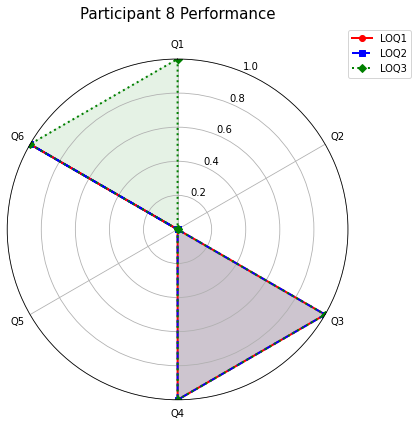

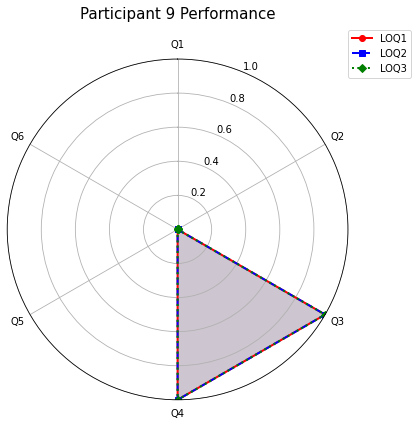

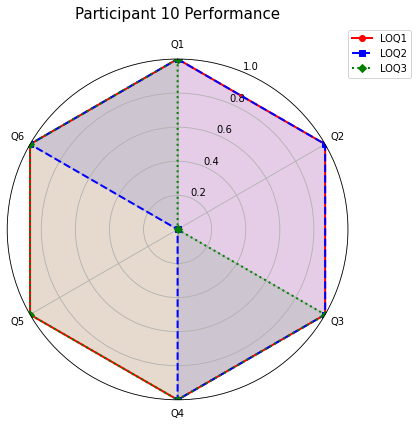

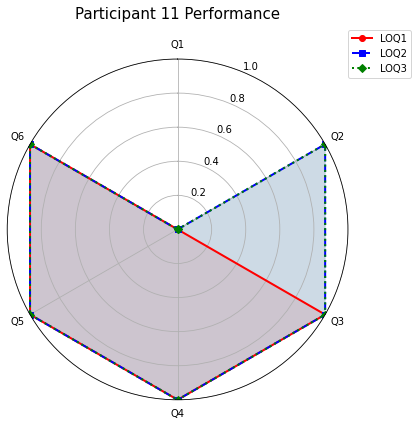

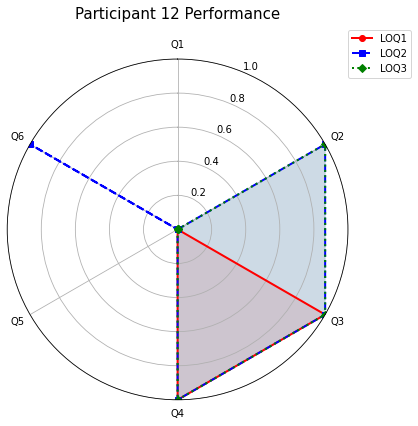

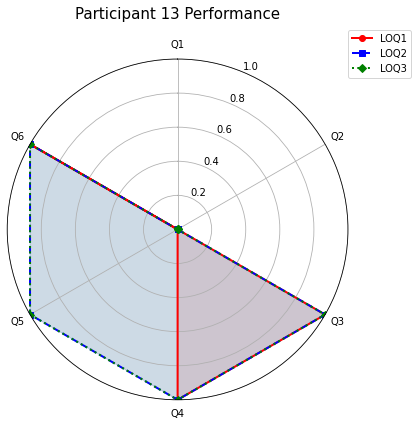

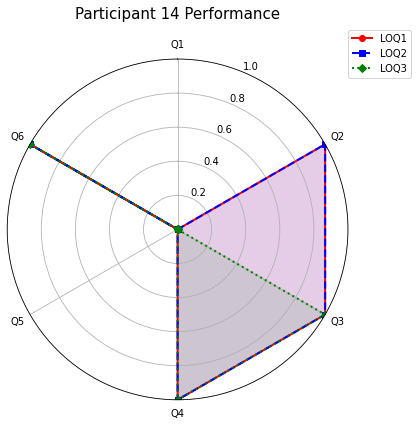

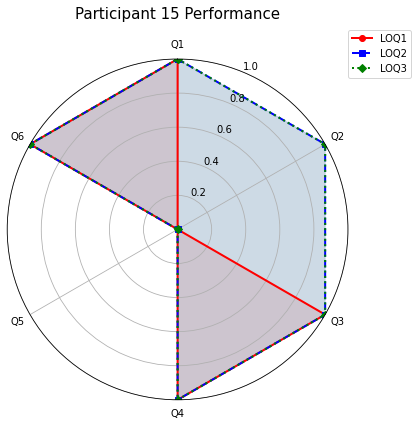

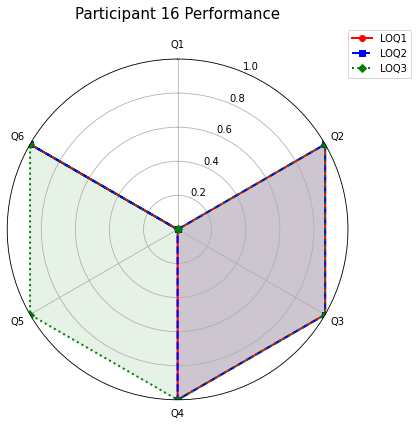

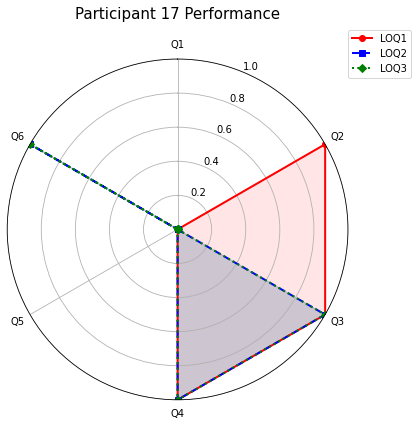

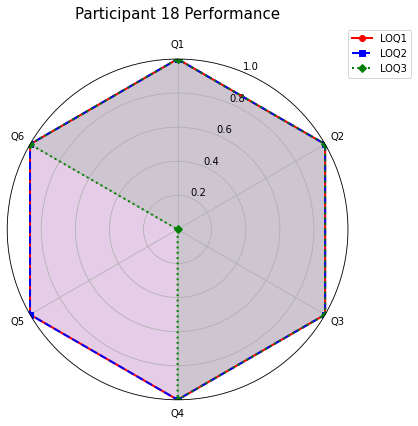

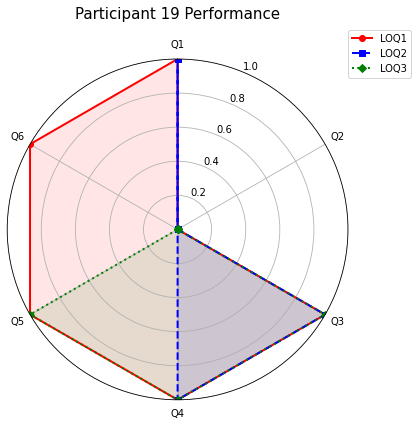

In [5]:
columns_of_interest = ['Q1LOQ1', 'Q2LOQ1', 'Q3LOQ1', 'Q4LOQ1', 'Q5LOQ1', 'Q6LOQ1',
                       'Q1LOQ2', 'Q2LOQ2', 'Q3LOQ2', 'Q4LOQ2', 'Q5LOQ2', 'Q6LOQ2',
                       'Q1LOQ3', 'Q2LOQ3', 'Q3LOQ3', 'Q4LOQ3', 'Q5LOQ3', 'Q6LOQ3']

# Select the columns of interest and create a participant identifier
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Fill missing values with 0
filtered_data.fillna(0, inplace=True)

# Function to create radar chart with markers for a single participant
def create_radar_chart_single_participant(participant_data, participant_number):
    labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']
    num_vars = len(labels)

    # Setup radar chart
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop for the radar chart

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # LOQ1 data (first ring)
    values1 = participant_data[['Q1LOQ1', 'Q2LOQ1', 'Q3LOQ1', 'Q4LOQ1', 'Q5LOQ1', 'Q6LOQ1']].values.flatten().tolist()
    values1 += values1[:1]  # Close the loop
    ax.plot(angles, values1, color='red', linewidth=2, label='LOQ1', linestyle='solid', marker='o')
    ax.fill(angles, values1, color='red', alpha=0.1)

    # LOQ2 data (second ring)
    values2 = participant_data[['Q1LOQ2', 'Q2LOQ2', 'Q3LOQ2', 'Q4LOQ2', 'Q5LOQ2', 'Q6LOQ2']].values.flatten().tolist()
    values2 += values2[:1]  # Close the loop
    ax.plot(angles, values2, color='blue', linewidth=2, label='LOQ2', linestyle='dashed', marker='s')
    ax.fill(angles, values2, color='blue', alpha=0.1)

    # LOQ3 data (third ring)
    values3 = participant_data[['Q1LOQ3', 'Q2LOQ3', 'Q3LOQ3', 'Q4LOQ3', 'Q5LOQ3', 'Q6LOQ3']].values.flatten().tolist()
    values3 += values3[:1]  # Close the loop
    ax.plot(angles, values3, color='green', linewidth=2, label='LOQ3', linestyle='dotted', marker='D')
    ax.fill(angles, values3, color='green', alpha=0.1)

    # Customize the radar chart
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axis per variable and add labels
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)

    # Set the range for each question score (0 = incorrect, 1 = correct)
    ax.set_ylim(0, 1)

    # Add a title and legend
    plt.title(f'Participant {participant_number} Performance', size=15, color='black', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

    # Show the plot
    plt.tight_layout()
    plt.show()

# Loop through all participants and generate separate radar charts for each
for participant in filtered_data['Participant'].unique():
    participant_data = filtered_data[filtered_data['Participant'] == participant]
    create_radar_chart_single_participant(participant_data, participant)

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


<AxesSubplot:ylabel='Participant'>

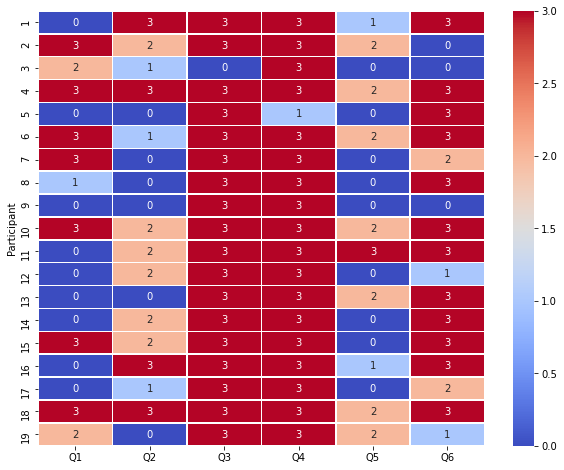

In [4]:
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Aggregating the correct answers for each question across LOQ1, LOQ2, and LOQ3
# For each participant, sum the values across LOQ1, LOQ2, and LOQ3 for each question
heatmap_data = pd.DataFrame()

# Sum the correct answers (1 means correct) for each question
heatmap_data['Q1'] = filtered_data[['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3']].sum(axis=1)
heatmap_data['Q2'] = filtered_data[['Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3']].sum(axis=1)
heatmap_data['Q3'] = filtered_data[['Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3']].sum(axis=1)
heatmap_data['Q4'] = filtered_data[['Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3']].sum(axis=1)
heatmap_data['Q5'] = filtered_data[['Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3']].sum(axis=1)
heatmap_data['Q6'] = filtered_data[['Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3']].sum(axis=1)

# Adding participant identifiers
heatmap_data['Participant'] = filtered_data['Participant']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=True)


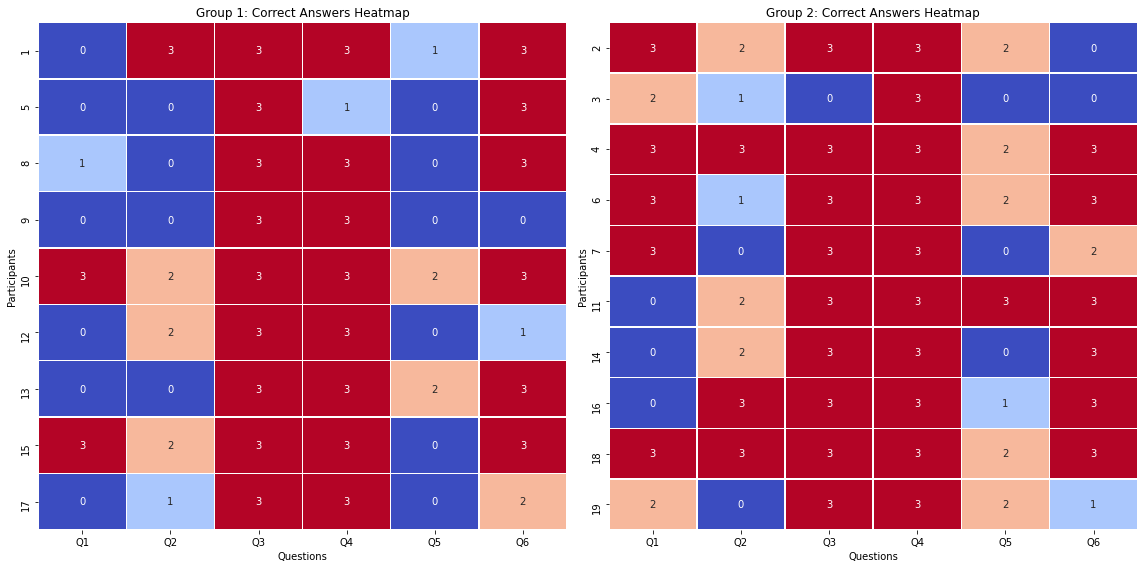

In [6]:
heatmap_data = pd.DataFrame()

# Sum the correct answers (1 means correct) for each question
heatmap_data['Q1'] = filtered_data[['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3']].sum(axis=1)
heatmap_data['Q2'] = filtered_data[['Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3']].sum(axis=1)
heatmap_data['Q3'] = filtered_data[['Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3']].sum(axis=1)
heatmap_data['Q4'] = filtered_data[['Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3']].sum(axis=1)
heatmap_data['Q5'] = filtered_data[['Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3']].sum(axis=1)
heatmap_data['Q6'] = filtered_data[['Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3']].sum(axis=1)

# Adding participant identifiers and group
heatmap_data['Participant'] = filtered_data['Participant']
heatmap_data['Group'] = filtered_data['Group']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Create two separate dataframes for each group
group_1_data = heatmap_data[heatmap_data['Group'] == 1].drop('Group', axis=1)
group_2_data = heatmap_data[heatmap_data['Group'] == 2].drop('Group', axis=1)

# Plotting the heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap for Group 1
sns.heatmap(group_1_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=False, ax=ax1)
ax1.set_title('Group 1: Correct Answers Heatmap')
ax1.set_xlabel('Questions')
ax1.set_ylabel('Participants')

# Heatmap for Group 2
sns.heatmap(group_2_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=False, ax=ax2)
ax2.set_title('Group 2: Correct Answers Heatmap')
ax2.set_xlabel('Questions')
ax2.set_ylabel('Participants')

# Show the plot
plt.tight_layout()
plt.show()

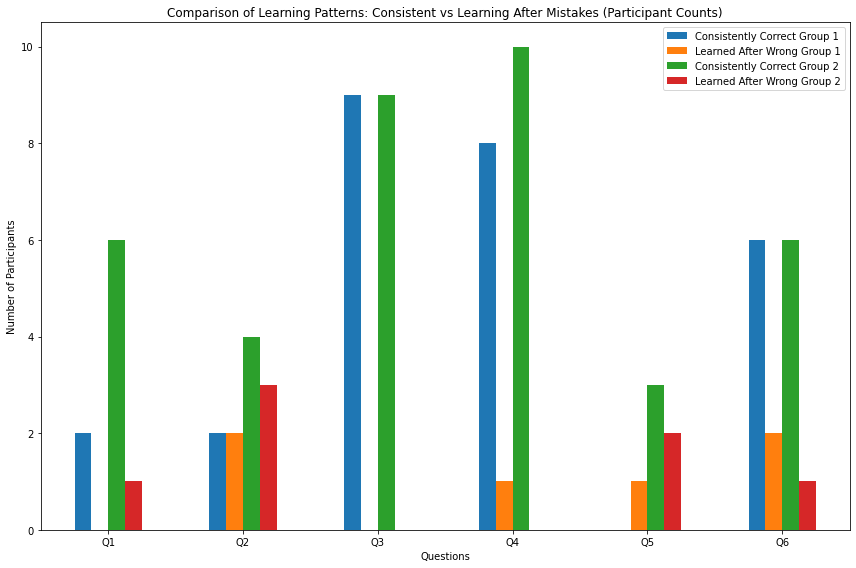

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Count the number of participants for each question who were consistently correct or learned after getting it wrong
consistent_correct_group1 = consistent_correct[consistent_correct['Group'] == 1].drop(['Group', 'Participant'], axis=1).sum()
consistent_correct_group2 = consistent_correct[consistent_correct['Group'] == 2].drop(['Group', 'Participant'], axis=1).sum()

learned_after_wrong_group1 = learned_after_wrong[learned_after_wrong['Group'] == 1].drop(['Group', 'Participant'], axis=1).sum()
learned_after_wrong_group2 = learned_after_wrong[learned_after_wrong['Group'] == 2].drop(['Group', 'Participant'], axis=1).sum()

# Create a DataFrame for visualization
visualization_df = pd.DataFrame({
    'Consistently Correct Group 1': consistent_correct_group1,
    'Learned After Wrong Group 1': learned_after_wrong_group1,
    'Consistently Correct Group 2': consistent_correct_group2,
    'Learned After Wrong Group 2': learned_after_wrong_group2
})

# Plotting grouped bar charts for comparison (with participant counts)
visualization_df.plot(kind='bar', figsize=(12, 8))

# Customize the plot
plt.title('Comparison of Learning Patterns: Consistent vs Learning After Mistakes (Participant Counts)')
plt.xlabel('Questions')
plt.ylabel('Number of Participants')
plt.xticks(rotation=0)
plt.legend(loc='best')

# Show the plot
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


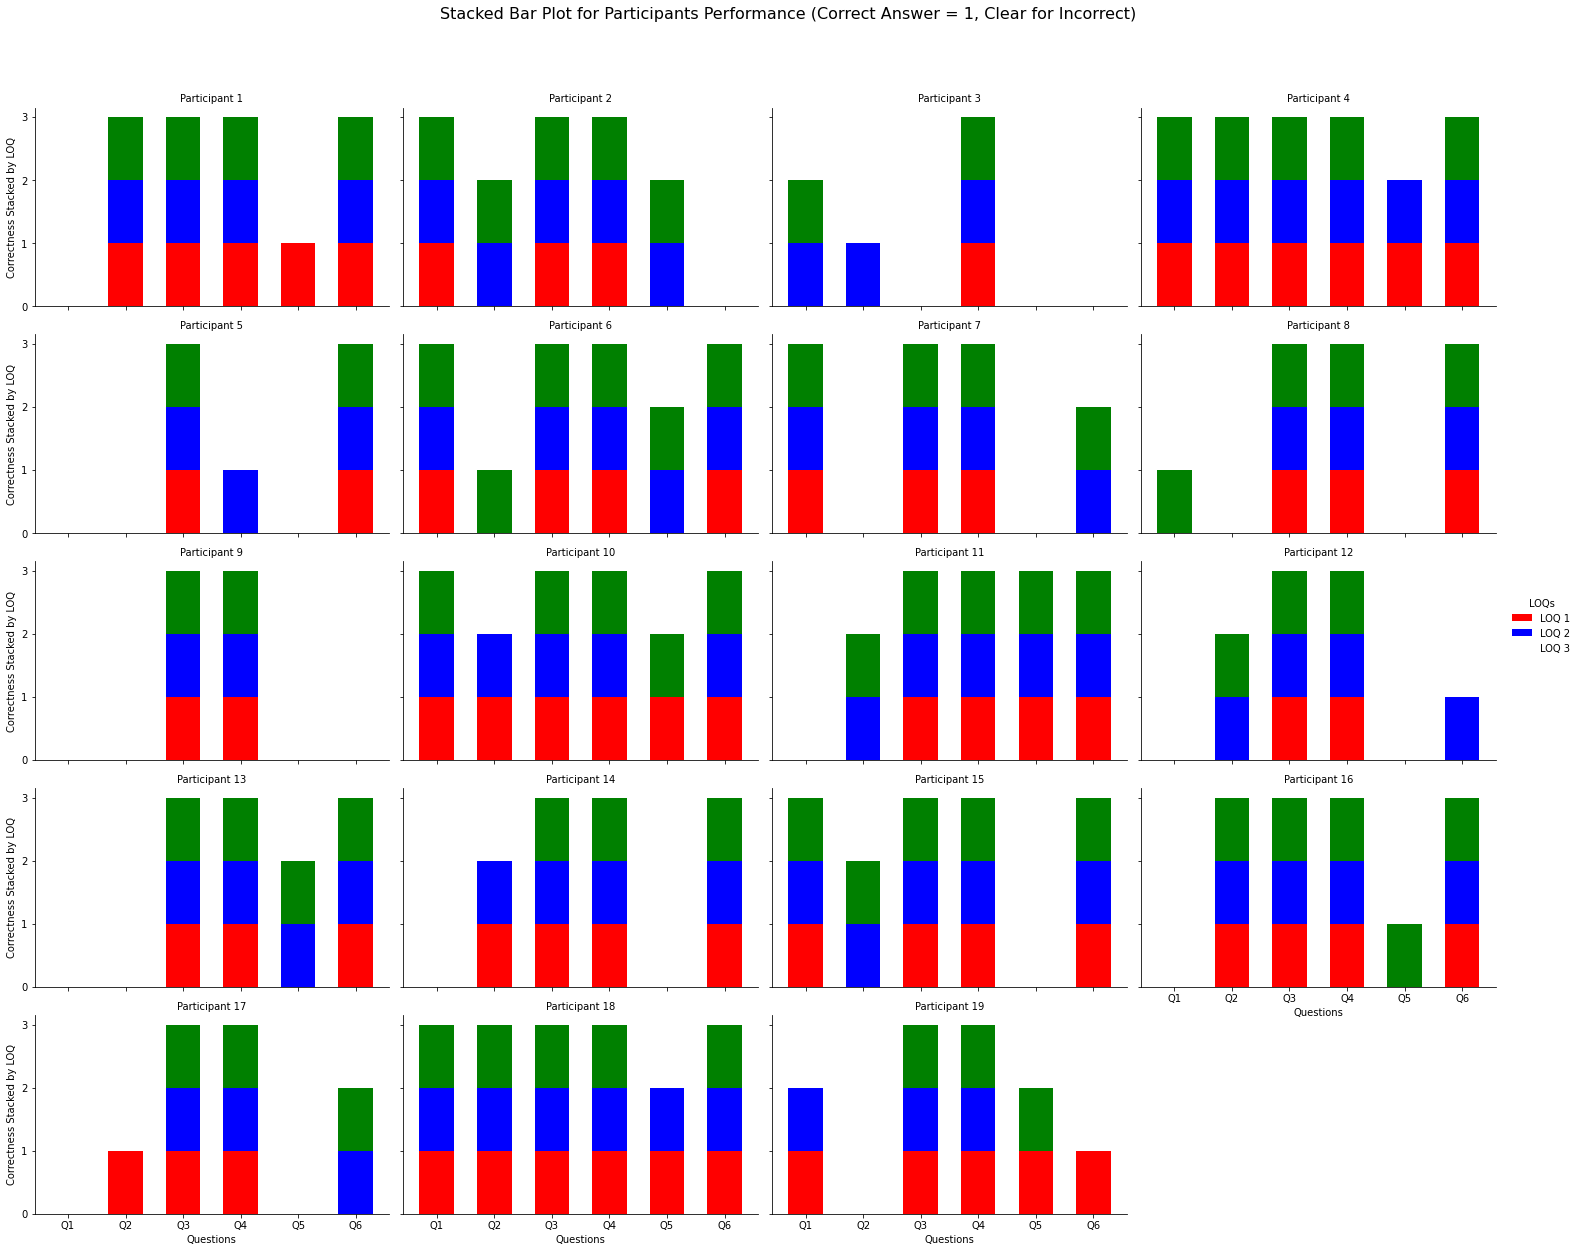

In [5]:
filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Melt the data for easier plotting
melted_data = pd.melt(filtered_data, id_vars=['Participant', 'Group'], var_name='Question_LOQ', value_name='Score')

# Extract the question number and LOQ (time point)
melted_data['Question'] = melted_data['Question_LOQ'].str.extract(r'(Q\d)')
melted_data['LOQ'] = melted_data['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

# Convert Question to a numeric value for sorting and plotting
melted_data['Question'] = melted_data['Question'].str.replace('Q', '').astype(int)

# Pivot the data to have the LOQs in separate columns for stacking
stacked_data = melted_data.pivot_table(index=['Participant', 'Question'], columns='LOQ', values='Score').fillna(0)

# Plot the stacked bar plot for each participant
def plot_stacked_bars_with_clear(data, **kwargs):
    participant = kwargs.get('col_name', 'Participant')
    data = data.reset_index()
    
    # Define colors for each LOQ: Red for LOQ1, Blue for LOQ2, Green for LOQ3
    loq_colors = {1: 'red', 2: 'blue', 3: 'green'}
    
    # Plot LOQ1, LOQ2, and LOQ3 stacked with clear (transparent) sections where incorrect
    plt.bar(data['Question'], data[1], color=[loq_colors[1] if val > 0 else 'none' for val in data[1]], label='LOQ 1', width=0.6)
    plt.bar(data['Question'], data[2], bottom=data[1], color=[loq_colors[2] if val > 0 else 'none' for val in data[2]], label='LOQ 2', width=0.6)
    plt.bar(data['Question'], data[3], bottom=data[1] + data[2], color=[loq_colors[3] if val > 0 else 'none' for val in data[3]], label='LOQ 3', width=0.6)

# Create a FacetGrid for participants
g = sns.FacetGrid(stacked_data.reset_index(), col="Participant", col_wrap=4, height=3.5, aspect=1.5)

# Apply the plotting function to each Facet
g.map_dataframe(plot_stacked_bars_with_clear)

# Customize the plot
g.set_titles("Participant {col_name}")
g.set_axis_labels("Questions", "Correctness Stacked by LOQ")
g.set(xticks=[1, 2, 3, 4, 5, 6], xticklabels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6'])
g.set(yticks=[0, 1, 2, 3], yticklabels=['0', '1', '2', '3'])

# Adjust the overall layout
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Stacked Bar Plot for Participants Performance (Correct Answer = 1, Clear for Incorrect)', fontsize=16)

# Add a legend
g.add_legend(title="LOQs", label_order=['LOQ 1', 'LOQ 2', 'LOQ 3'])

plt.show()

In [6]:
import scipy.stats as stats

filtered_data = data[['Group'] + columns_of_interest]
filtered_data['Participant'] = filtered_data.index + 1

# Sum the correctness across LOQ1, LOQ2, and LOQ3 for each question (1 if correct at least once)
for i in range(1, 7):  # for questions Q1 to Q6
    filtered_data[f'Q{i}_total'] = filtered_data[[f'Q{i}LOQ1', f'Q{i}LOQ2', f'Q{i}LOQ3']].sum(axis=1)
    filtered_data[f'Q{i}_correct'] = (filtered_data[f'Q{i}_total'] > 0).astype(int)  # If any LOQ is correct, mark 1

# Count correct responses by group for each question
grouped_data = filtered_data.groupby('Group').sum()[[f'Q{i}_correct' for i in range(1, 7)]]
grouped_data.columns = [f'Correct_Q{i}' for i in range(1, 7)]  # Rename columns

# Display the counts of correct responses per group
print("Counts of Correct Responses by Group")
print(grouped_data)

# Perform Wilcoxon rank-sum test (non-parametric) to compare groups for each question
results = {}
for i in range(1, 7):
    group1_scores = filtered_data[filtered_data['Group'] == 1][f'Q{i}_correct']
    group2_scores = filtered_data[filtered_data['Group'] == 2][f'Q{i}_correct']
    
    # Wilcoxon rank-sum test
    stat, p_value = stats.ranksums(group1_scores, group2_scores)
    results[f'Q{i}'] = {'statistic': stat, 'p_value': p_value}

# Convert results to DataFrame for better display
results_df = pd.DataFrame(results).T
print("\nWilcoxon Rank-Sum Test Results (Group 1 vs. Group 2 for Each Question)")
print(results_df)

Counts of Correct Responses by Group
       Correct_Q1  Correct_Q2  Correct_Q3  Correct_Q4  Correct_Q5  Correct_Q6
Group                                                                        
1               3           5           9           9           3           8
2               7           8           9          10           7           8

Wilcoxon Rank-Sum Test Results (Group 1 vs. Group 2 for Each Question)
    statistic   p_value
Q1  -1.347219  0.177910
Q2  -0.898146  0.369108
Q3   0.367423  0.713303
Q4   0.000000  1.000000
Q5  -1.347219  0.177910
Q6   0.326599  0.743971


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docum

In [7]:
breakdown = {}

# For each question (Q1 to Q6), calculate how many participants in each group got it correct per LOQ
for i in range(1, 7):
    breakdown[f'Q{i}_LOQ1'] = filtered_data.groupby('Group')[f'Q{i}LOQ1'].sum()
    breakdown[f'Q{i}_LOQ2'] = filtered_data.groupby('Group')[f'Q{i}LOQ2'].sum()
    breakdown[f'Q{i}_LOQ3'] = filtered_data.groupby('Group')[f'Q{i}LOQ3'].sum()

# Convert the breakdown into a DataFrame
breakdown_df = pd.DataFrame(breakdown)

# Display the counts of correct responses per group, per LOQ, per question
print("Detailed Breakdown of Correct Responses per Group (Based on LOQ and Question):")
print(breakdown_df)



Detailed Breakdown of Correct Responses per Group (Based on LOQ and Question):
       Q1_LOQ1  Q1_LOQ2  Q1_LOQ3  Q2_LOQ1  Q2_LOQ2  Q2_LOQ3  Q3_LOQ1  Q3_LOQ2  \
Group                                                                           
1            2        2        3        3        4        3        9        9   
2            6        7        6        4        7        6        9        9   

       Q3_LOQ3  Q4_LOQ1  Q4_LOQ2  Q4_LOQ3  Q5_LOQ1  Q5_LOQ2  Q5_LOQ3  Q6_LOQ1  \
Group                                                                           
1            9        8        9        8        2        1        2        6   
2            9       10       10       10        4        5        5        7   

       Q6_LOQ2  Q6_LOQ3  
Group                    
1            8        7  
2            7        7  


In [8]:
average_data = {}

# For each LOQ, calculate the mean number of correct answers per group
for loq in range(1, 4):  # LOQ1 to LOQ3
    correct_cols = [f'Q{i}LOQ{loq}' for i in range(1, 7)]
    average_data[f'Average_LOQ{loq}'] = filtered_data.groupby('Group')[correct_cols].mean().sum(axis=1)

# Calculate the total average number of correct answers across all LOQs (LOQ1 + LOQ2 + LOQ3)
for group in filtered_data['Group'].unique():
    group_data = filtered_data[filtered_data['Group'] == group]
    total_correct_per_participant = group_data[[f'Q{i}LOQ{loq}' for i in range(1, 7) for loq in range(1, 4)]].sum(axis=1)
    average_data[f'Average_Total_Group_{group}'] = total_correct_per_participant.mean()

# Convert the results into a DataFrame for display
average_data_df = pd.DataFrame(average_data)

print("Average Number of Correct Answers per Group and LOQ, as well as Total:")
print(average_data_df)

Average Number of Correct Answers per Group and LOQ, as well as Total:
       Average_LOQ1  Average_LOQ2  Average_LOQ3  Average_Total_Group_1  \
Group                                                                    
1          3.333333      3.666667      3.555556              10.555556   
2          4.000000      4.500000      4.300000              10.555556   

       Average_Total_Group_2  
Group                         
1                       12.8  
2                       12.8  


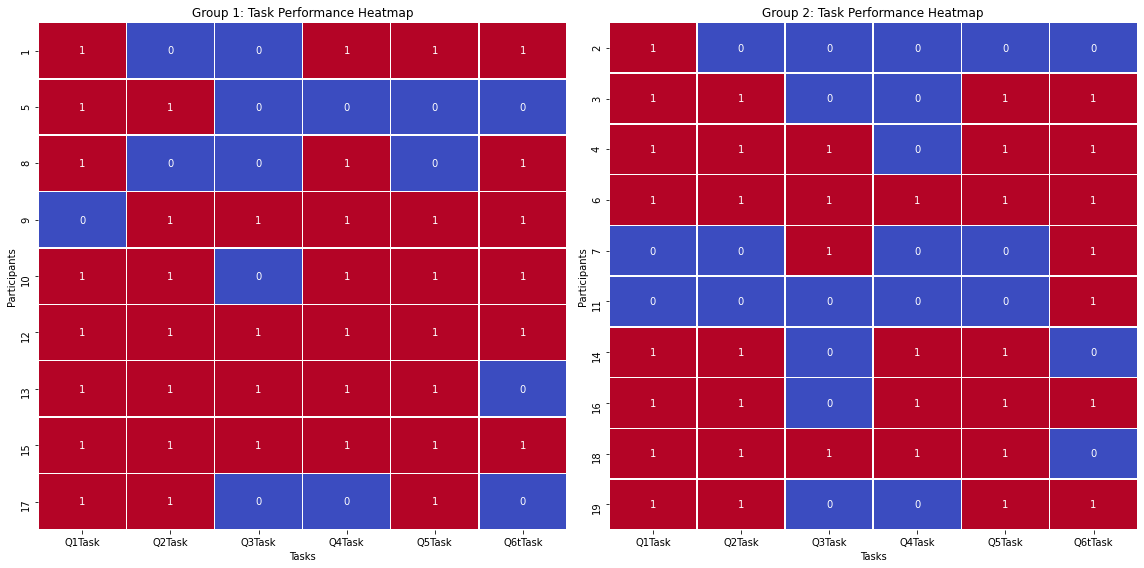

In [9]:
task_columns = ['Q1Task', 'Q2Task', 'Q3Task', 'Q4Task', 'Q5Task', 'Q6tTask']

# Ensure that the data has a 'Group' column, and create a 'Participant' column using the index if it doesn't exist
if 'Participant' not in data.columns:
    data['Participant'] = data.index + 1  # Create Participant column based on the index

# Select the necessary columns from the original dataset (including Group and Participant)
filtered_data = data[['Group', 'Participant'] + task_columns]

# Create a new DataFrame to store the task scores
heatmap_data = pd.DataFrame()

# Add task scores for each question (assuming 1 means correct and 0 means incorrect)
for task in task_columns:
    heatmap_data[task] = filtered_data[task]

# Adding participant identifiers and group
heatmap_data['Participant'] = filtered_data['Participant']
heatmap_data['Group'] = filtered_data['Group']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Create two separate dataframes for each group
group_1_data = heatmap_data[heatmap_data['Group'] == 1].drop('Group', axis=1)
group_2_data = heatmap_data[heatmap_data['Group'] == 2].drop('Group', axis=1)

# Plotting the heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap for Group 1
sns.heatmap(group_1_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=False, ax=ax1)
ax1.set_title('Group 1: Task Performance Heatmap')
ax1.set_xlabel('Tasks')
ax1.set_ylabel('Participants')

# Heatmap for Group 2
sns.heatmap(group_2_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=False, ax=ax2)
ax2.set_title('Group 2: Task Performance Heatmap')
ax2.set_xlabel('Tasks')
ax2.set_ylabel('Participants')

# Show the plot
plt.tight_layout()
plt.show()


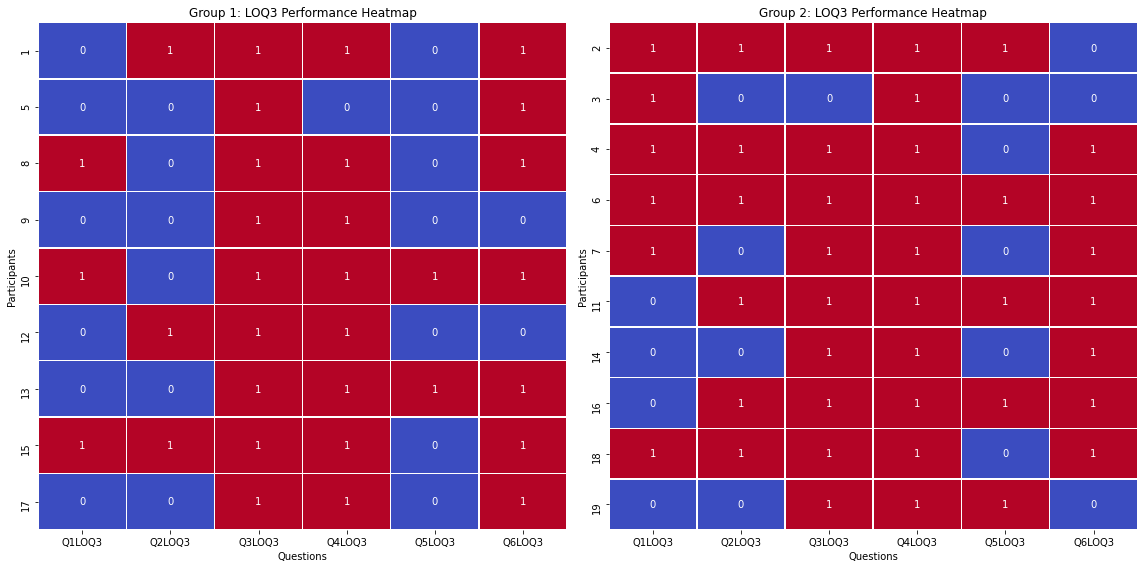

In [13]:
loq3_columns = ['Q1LOQ3', 'Q2LOQ3', 'Q3LOQ3', 'Q4LOQ3', 'Q5LOQ3', 'Q6LOQ3']

# Ensure that the data has a 'Group' column, and create a 'Participant' column using the index if it doesn't exist
if 'Participant' not in data.columns:
    data['Participant'] = data.index + 1  # Create Participant column based on the index

# Select the necessary columns from the original dataset (including Group and Participant)
filtered_data = data[['Group', 'Participant'] + loq3_columns]

# Create a new DataFrame to store the LOQ3 scores
heatmap_data = pd.DataFrame()

# Add LOQ3 scores for each question
for col in loq3_columns:
    heatmap_data[col] = filtered_data[col]

# Adding participant identifiers and group
heatmap_data['Participant'] = filtered_data['Participant']
heatmap_data['Group'] = filtered_data['Group']

# Set Participant as the index for better visualization
heatmap_data.set_index('Participant', inplace=True)

# Create two separate dataframes for each group
group_1_data = heatmap_data[heatmap_data['Group'] == 1].drop('Group', axis=1)
group_2_data = heatmap_data[heatmap_data['Group'] == 2].drop('Group', axis=1)

# Plotting the heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap for Group 1
sns.heatmap(group_1_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=False, ax=ax1)
ax1.set_title('Group 1: LOQ3 Performance Heatmap')
ax1.set_xlabel('Questions')
ax1.set_ylabel('Participants')

# Heatmap for Group 2
sns.heatmap(group_2_data, annot=True, cmap='coolwarm', linewidths=0.5, cbar=False, ax=ax2)
ax2.set_title('Group 2: LOQ3 Performance Heatmap')
ax2.set_xlabel('Questions')
ax2.set_ylabel('Participants')

# Show the plot
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # This is added back by InteractiveShellApp.init_path()
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


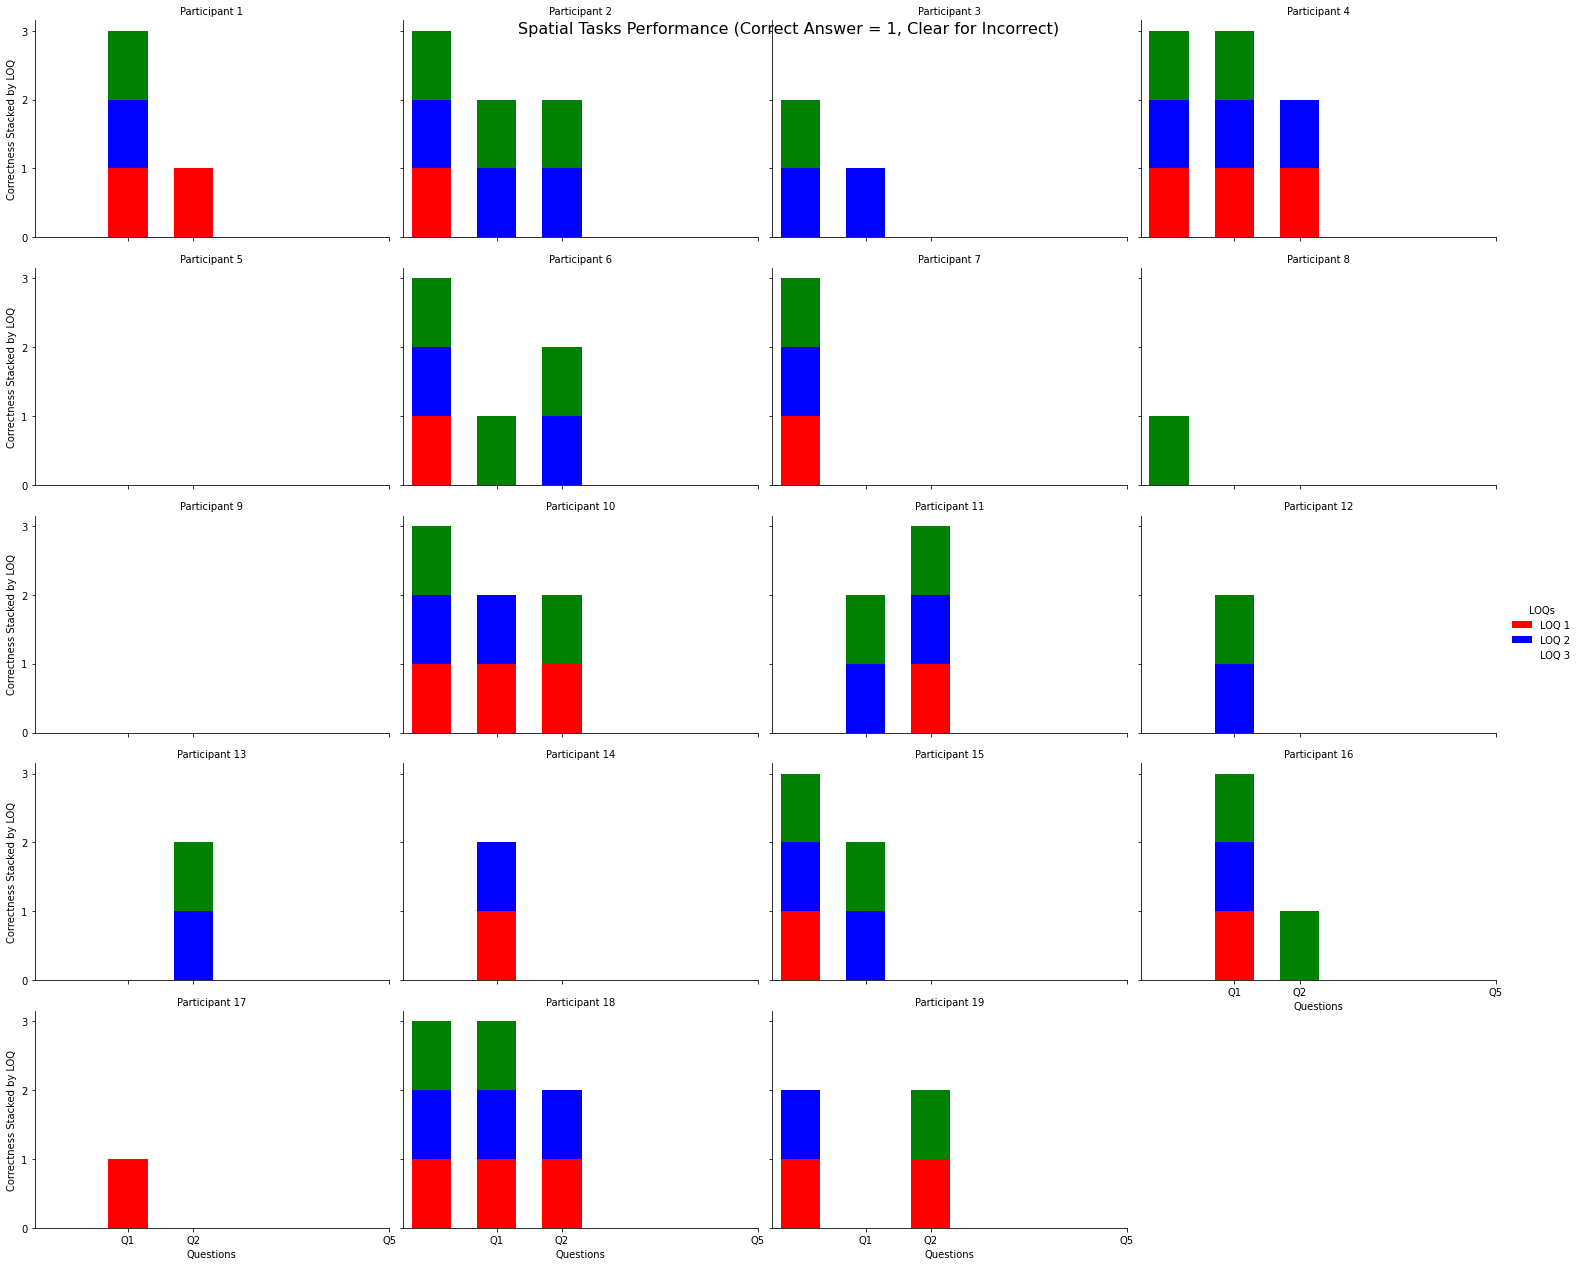

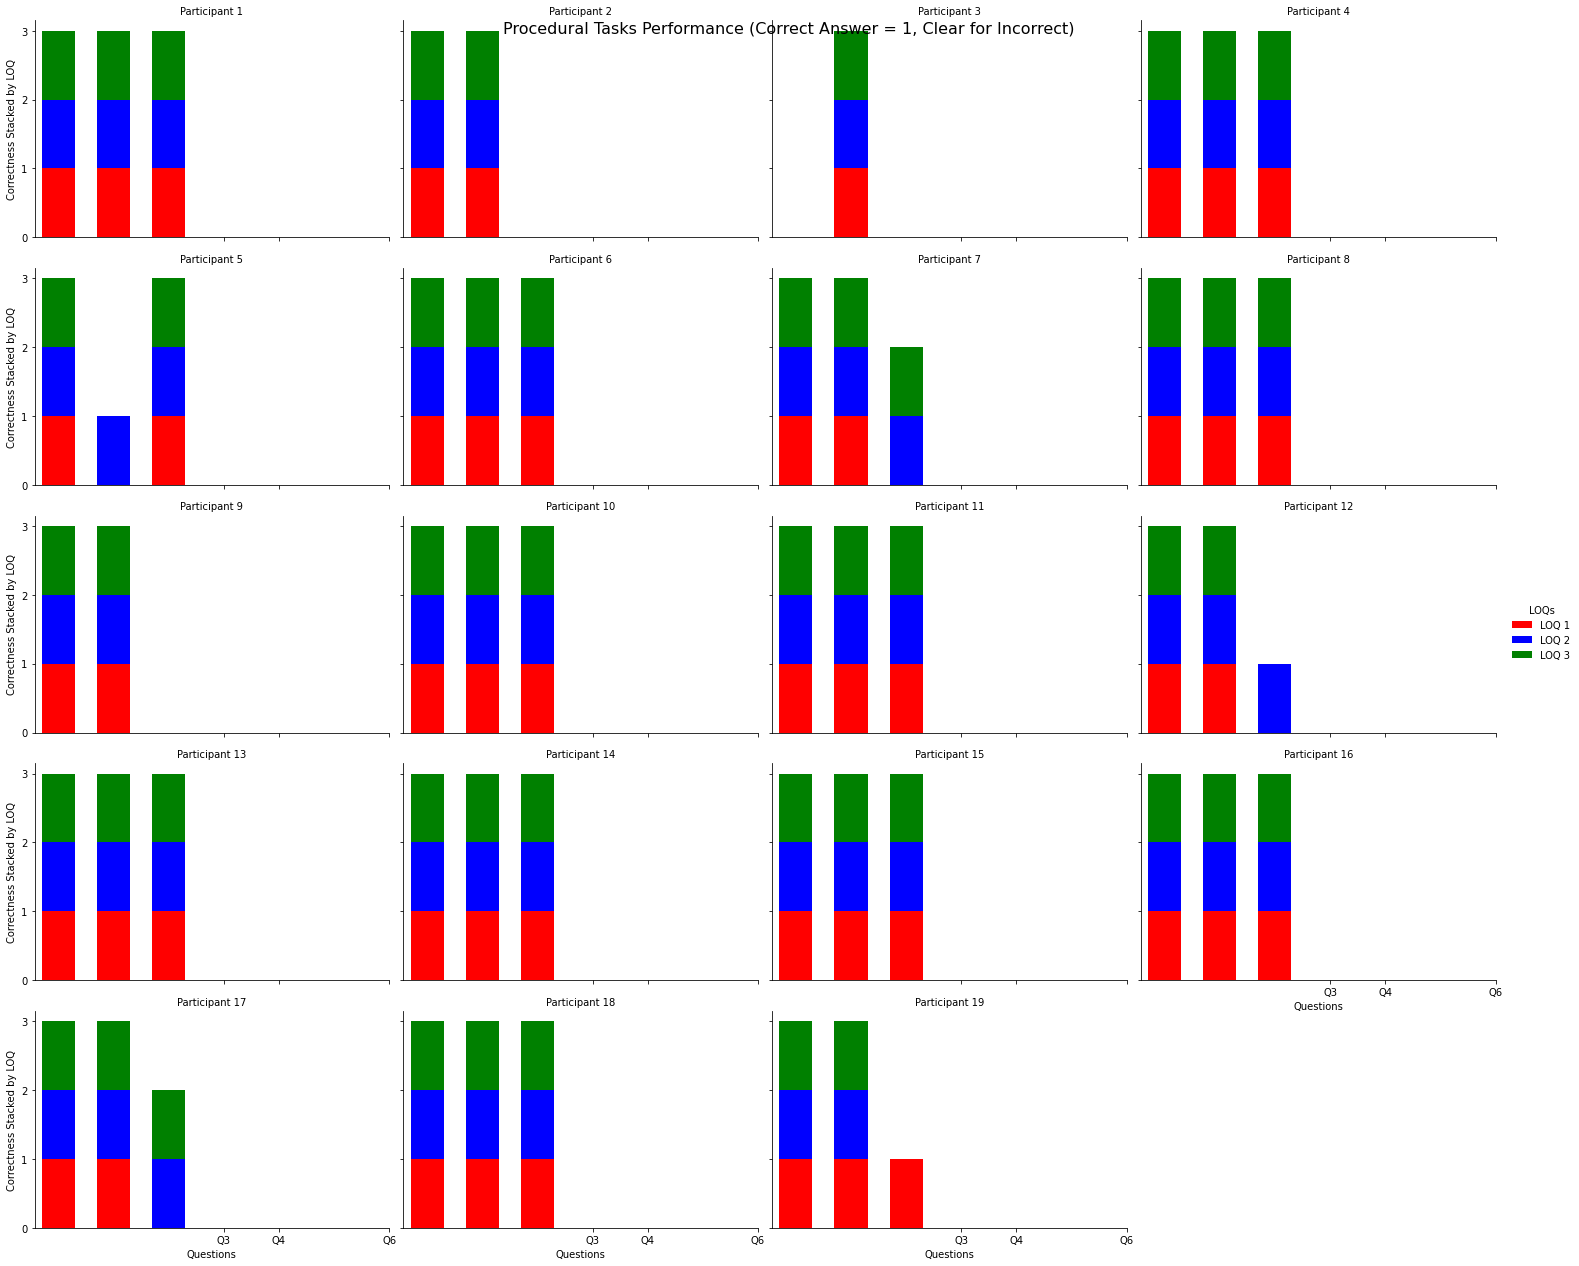

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define columns for spatial and procedural questions
spatial_columns = ['Q1LOQ1', 'Q1LOQ2', 'Q1LOQ3', 'Q2LOQ1', 'Q2LOQ2', 'Q2LOQ3', 'Q5LOQ1', 'Q5LOQ2', 'Q5LOQ3']
procedural_columns = ['Q3LOQ1', 'Q3LOQ2', 'Q3LOQ3', 'Q4LOQ1', 'Q4LOQ2', 'Q4LOQ3', 'Q6LOQ1', 'Q6LOQ2', 'Q6LOQ3']

# Filter spatial data
spatial_data = data[['Group'] + spatial_columns]
spatial_data['Participant'] = spatial_data.index + 1

# Melt the spatial data for easier plotting
melted_spatial_data = pd.melt(spatial_data, id_vars=['Participant', 'Group'], var_name='Question_LOQ', value_name='Score')
melted_spatial_data['Question'] = melted_spatial_data['Question_LOQ'].str.extract(r'(Q\d)')
melted_spatial_data['LOQ'] = melted_spatial_data['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

# Filter procedural data
procedural_data = data[['Group'] + procedural_columns]
procedural_data['Participant'] = procedural_data.index + 1

# Melt the procedural data for easier plotting
melted_procedural_data = pd.melt(procedural_data, id_vars=['Participant', 'Group'], var_name='Question_LOQ', value_name='Score')
melted_procedural_data['Question'] = melted_procedural_data['Question_LOQ'].str.extract(r'(Q\d)')
melted_procedural_data['LOQ'] = melted_procedural_data['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

# Define the function for plotting
def plot_stacked_bars(data, **kwargs):
    participant = kwargs.get('col_name', 'Participant')
    data = data.reset_index()
    
    # Define colors for each LOQ: Red for LOQ1, Blue for LOQ2, Green for LOQ3
    loq_colors = {1: 'red', 2: 'blue', 3: 'green'}
    
    # Plot LOQ1, LOQ2, and LOQ3 stacked with transparency for incorrect answers
    plt.bar(data['Question'], data[1], color=[loq_colors[1] if val > 0 else 'none' for val in data[1]], label='LOQ 1', width=0.6)
    plt.bar(data['Question'], data[2], bottom=data[1], color=[loq_colors[2] if val > 0 else 'none' for val in data[2]], label='LOQ 2', width=0.6)
    plt.bar(data['Question'], data[3], bottom=data[1] + data[2], color=[loq_colors[3] if val > 0 else 'none' for val in data[3]], label='LOQ 3', width=0.6)

# Create pivot tables for spatial and procedural data
stacked_spatial_data = melted_spatial_data.pivot_table(index=['Participant', 'Question'], columns='LOQ', values='Score').fillna(0)
stacked_procedural_data = melted_procedural_data.pivot_table(index=['Participant', 'Question'], columns='LOQ', values='Score').fillna(0)

# Create a FacetGrid for spatial tasks
g1 = sns.FacetGrid(stacked_spatial_data.reset_index(), col="Participant", col_wrap=4, height=3.5, aspect=1.5)
g1.map_dataframe(plot_stacked_bars)

# Customize the plot for spatial tasks
g1.set_titles("Participant {col_name}")
g1.set_axis_labels("Questions", "Correctness Stacked by LOQ")
g1.set(xticks=[1, 2, 5], xticklabels=['Q1', 'Q2', 'Q5'])
g1.set(yticks=[0, 1, 2, 3], yticklabels=['0', '1', '2', '3'])
g1.fig.suptitle('Spatial Tasks Performance (Correct Answer = 1, Clear for Incorrect)', fontsize=16)
g1.add_legend(title="LOQs", label_order=['LOQ 1', 'LOQ 2', 'LOQ 3'])

# Create a FacetGrid for procedural tasks
g2 = sns.FacetGrid(stacked_procedural_data.reset_index(), col="Participant", col_wrap=4, height=3.5, aspect=1.5)
g2.map_dataframe(plot_stacked_bars)

# Customize the plot for procedural tasks
g2.set_titles("Participant {col_name}")
g2.set_axis_labels("Questions", "Correctness Stacked by LOQ")
g2.set(xticks=[3, 4, 6], xticklabels=['Q3', 'Q4', 'Q6'])
g2.set(yticks=[0, 1, 2, 3], yticklabels=['0', '1', '2', '3'])
g2.fig.suptitle('Procedural Tasks Performance (Correct Answer = 1, Clear for Incorrect)', fontsize=16)
g2.add_legend(title="LOQs", label_order=['LOQ 1', 'LOQ 2', 'LOQ 3'])

# Show the plots
plt.show()


In [8]:
import pandas as pd

# Filter spatial and procedural columns as before
spatial_columns = ['Q1LOQ1', 'Q2LOQ1', 'Q5LOQ1', 'Q1LOQ2', 'Q2LOQ2', 'Q5LOQ2']
procedural_columns = ['Q3LOQ1', 'Q4LOQ1', 'Q6LOQ1', 'Q3LOQ2', 'Q4LOQ2', 'Q6LOQ2']

# Filter data for spatial and procedural questions and add Group info
spatial_data = data[['Group'] + spatial_columns]
procedural_data = data[['Group'] + procedural_columns]

# Calculate total correct responses for LOQ1 and LOQ2 for spatial and procedural questions
spatial_data['Spatial_LOQ1_Correct'] = spatial_data[['Q1LOQ1', 'Q2LOQ1', 'Q5LOQ1']].sum(axis=1)
spatial_data['Spatial_LOQ2_Correct'] = spatial_data[['Q1LOQ2', 'Q2LOQ2', 'Q5LOQ2']].sum(axis=1)
procedural_data['Procedural_LOQ1_Correct'] = procedural_data[['Q3LOQ1', 'Q4LOQ1', 'Q6LOQ1']].sum(axis=1)
procedural_data['Procedural_LOQ2_Correct'] = procedural_data[['Q3LOQ2', 'Q4LOQ2', 'Q6LOQ2']].sum(axis=1)

# Function to categorize progression between LOQ1 and LOQ2
def analyze_transition(data, loq1_col, loq2_col):
    results = {
        'Stayed Correct': 0,
        'Became Incorrect': 0,
        'Stayed Incorrect': 0,
        'Became Correct': 0
    }
    
    for _, row in data.iterrows():
        loq1_score = row[loq1_col]
        loq2_score = row[loq2_col]
        
        # All questions are correct or incorrect if the score equals the number of questions (3)
        if loq1_score == 3:
            if loq2_score == 3:
                results['Stayed Correct'] += 1
            else:
                results['Became Incorrect'] += 1
        else:
            if loq2_score == 3:
                results['Became Correct'] += 1
            else:
                results['Stayed Incorrect'] += 1
                
    return results

# Analyze transitions for Group 1 and Group 2 separately
group_1_spatial = spatial_data[spatial_data['Group'] == 1]
group_2_spatial = spatial_data[spatial_data['Group'] == 2]

group_1_procedural = procedural_data[procedural_data['Group'] == 1]
group_2_procedural = procedural_data[procedural_data['Group'] == 2]

# Analyze transitions for each group
group_1_spatial_results = analyze_transition(group_1_spatial, 'Spatial_LOQ1_Correct', 'Spatial_LOQ2_Correct')
group_2_spatial_results = analyze_transition(group_2_spatial, 'Spatial_LOQ1_Correct', 'Spatial_LOQ2_Correct')

group_1_procedural_results = analyze_transition(group_1_procedural, 'Procedural_LOQ1_Correct', 'Procedural_LOQ2_Correct')
group_2_procedural_results = analyze_transition(group_2_procedural, 'Procedural_LOQ1_Correct', 'Procedural_LOQ2_Correct')

# Display results
import pprint
print("Group 1 Spatial Transition from LOQ1 to LOQ2:")
pprint.pprint(group_1_spatial_results)

print("\nGroup 2 Spatial Transition from LOQ1 to LOQ2:")
pprint.pprint(group_2_spatial_results)

print("\nGroup 1 Procedural Transition from LOQ1 to LOQ2:")
pprint.pprint(group_1_procedural_results)

print("\nGroup 2 Procedural Transition from LOQ1 to LOQ2:")
pprint.pprint(group_2_procedural_results)


Group 1 Spatial Transition from LOQ1 to LOQ2:
{'Became Correct': 0,
 'Became Incorrect': 1,
 'Stayed Correct': 0,
 'Stayed Incorrect': 8}

Group 2 Spatial Transition from LOQ1 to LOQ2:
{'Became Correct': 1,
 'Became Incorrect': 0,
 'Stayed Correct': 2,
 'Stayed Incorrect': 7}

Group 1 Procedural Transition from LOQ1 to LOQ2:
{'Became Correct': 3,
 'Became Incorrect': 0,
 'Stayed Correct': 5,
 'Stayed Incorrect': 1}

Group 2 Procedural Transition from LOQ1 to LOQ2:
{'Became Correct': 1,
 'Became Incorrect': 1,
 'Stayed Correct': 6,
 'Stayed Incorrect': 2}


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  if sys.path[0] == '':
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the doc

In [11]:
import pandas as pd

# Define the spatial and procedural columns for LOQ1 and LOQ2 separately
spatial_loq1_columns = ['Q1LOQ1', 'Q2LOQ1', 'Q5LOQ1']
spatial_loq2_columns = ['Q1LOQ2', 'Q2LOQ2', 'Q5LOQ2']

procedural_loq1_columns = ['Q3LOQ1', 'Q4LOQ1', 'Q6LOQ1']
procedural_loq2_columns = ['Q3LOQ2', 'Q4LOQ2', 'Q6LOQ2']

# Filter data for spatial and procedural questions and add Group info
spatial_data = data[['Group'] + spatial_loq1_columns + spatial_loq2_columns]
procedural_data = data[['Group'] + procedural_loq1_columns + procedural_loq2_columns]
spatial_data['Participant'] = spatial_data.index + 1
procedural_data['Participant'] = procedural_data.index + 1

# Group by 'Group' and sum correct answers for each LOQ separately
spatial_loq1_correct_counts = spatial_data.groupby('Group')[spatial_loq1_columns].sum()
spatial_loq2_correct_counts = spatial_data.groupby('Group')[spatial_loq2_columns].sum()

procedural_loq1_correct_counts = procedural_data.groupby('Group')[procedural_loq1_columns].sum()
procedural_loq2_correct_counts = procedural_data.groupby('Group')[procedural_loq2_columns].sum()

# Find the questions with the fewest correct answers for LOQ1 and LOQ2
spatial_challenges_loq1 = spatial_loq1_correct_counts.idxmin(axis=1)
spatial_challenges_loq2 = spatial_loq2_correct_counts.idxmin(axis=1)

procedural_challenges_loq1 = procedural_loq1_correct_counts.idxmin(axis=1)
procedural_challenges_loq2 = procedural_loq2_correct_counts.idxmin(axis=1)

# Function to get participants who got a specific question wrong
def get_challenged_participants(data, question):
    # Find participants who got the question wrong (score == 0)
    challenged_participants = data[data[question] == 0]['Participant'].tolist()
    return challenged_participants

# Identify participants who struggled with the challenging questions for each LOQ
group_1_spatial_challenged_participants_loq1 = get_challenged_participants(
    spatial_data[spatial_data['Group'] == 1], spatial_challenges_loq1[1]
)
group_2_spatial_challenged_participants_loq1 = get_challenged_participants(
    spatial_data[spatial_data['Group'] == 2], spatial_challenges_loq1[2]
)

group_1_spatial_challenged_participants_loq2 = get_challenged_participants(
    spatial_data[spatial_data['Group'] == 1], spatial_challenges_loq2[1]
)
group_2_spatial_challenged_participants_loq2 = get_challenged_participants(
    spatial_data[spatial_data['Group'] == 2], spatial_challenges_loq2[2]
)

group_1_procedural_challenged_participants_loq1 = get_challenged_participants(
    procedural_data[procedural_data['Group'] == 1], procedural_challenges_loq1[1]
)
group_2_procedural_challenged_participants_loq1 = get_challenged_participants(
    procedural_data[procedural_data['Group'] == 2], procedural_challenges_loq1[2]
)

group_1_procedural_challenged_participants_loq2 = get_challenged_participants(
    procedural_data[procedural_data['Group'] == 1], procedural_challenges_loq2[1]
)
group_2_procedural_challenged_participants_loq2 = get_challenged_participants(
    procedural_data[procedural_data['Group'] == 2], procedural_challenges_loq2[2]
)

# Display the results for each LOQ and question type
import pprint
print("Most challenging spatial questions for LOQ1 and LOQ2:")
print("Group 1 - LOQ1:", spatial_challenges_loq1[1])
print("Group 1 - LOQ2:", spatial_challenges_loq2[1])
print("Group 2 - LOQ1:", spatial_challenges_loq1[2])
print("Group 2 - LOQ2:", spatial_challenges_loq2[2])

print("\nParticipants who struggled with these questions:")
print("Group 1 - Spatial LOQ1:", group_1_spatial_challenged_participants_loq1)
print("Group 1 - Spatial LOQ2:", group_1_spatial_challenged_participants_loq2)
print("Group 2 - Spatial LOQ1:", group_2_spatial_challenged_participants_loq1)
print("Group 2 - Spatial LOQ2:", group_2_spatial_challenged_participants_loq2)

print("\nMost challenging procedural questions for LOQ1 and LOQ2:")
print("Group 1 - LOQ1:", procedural_challenges_loq1[1])
print("Group 1 - LOQ2:", procedural_challenges_loq2[1])
print("Group 2 - LOQ1:", procedural_challenges_loq1[2])
print("Group 2 - LOQ2:", procedural_challenges_loq2[2])

print("\nParticipants who struggled with these questions:")
print("Group 1 - Procedural LOQ1:", group_1_procedural_challenged_participants_loq1)
print("Group 1 - Procedural LOQ2:", group_1_procedural_challenged_participants_loq2)
print("Group 2 - Procedural LOQ1:", group_2_procedural_challenged_participants_loq1)
print("Group 2 - Procedural LOQ2:", group_2_procedural_challenged_participants_loq2)


Most challenging spatial questions for LOQ1 and LOQ2:
Group 1 - LOQ1: Q1LOQ1
Group 1 - LOQ2: Q5LOQ2
Group 2 - LOQ1: Q2LOQ1
Group 2 - LOQ2: Q5LOQ2

Participants who struggled with these questions:
Group 1 - Spatial LOQ1: [1, 5, 8, 9, 12, 13, 17]
Group 1 - Spatial LOQ2: [1, 5, 8, 9, 10, 12, 15, 17]
Group 2 - Spatial LOQ1: [2, 3, 6, 7, 11, 19]
Group 2 - Spatial LOQ2: [3, 7, 14, 16, 19]

Most challenging procedural questions for LOQ1 and LOQ2:
Group 1 - LOQ1: Q6LOQ1
Group 1 - LOQ2: Q6LOQ2
Group 2 - LOQ1: Q6LOQ1
Group 2 - LOQ2: Q6LOQ2

Participants who struggled with these questions:
Group 1 - Procedural LOQ1: [9, 12, 17]
Group 1 - Procedural LOQ2: [9]
Group 2 - Procedural LOQ1: [2, 3, 7]
Group 2 - Procedural LOQ2: [2, 3, 19]


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  del sys.path[0]
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


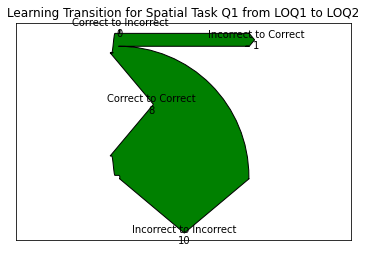

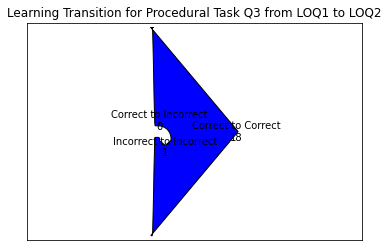

In [13]:
# Function to prepare transition counts for each question
def prepare_sankey_data(data, loq1_col, loq2_col):
    transitions = {
        'Correct to Correct': 0,
        'Correct to Incorrect': 0,
        'Incorrect to Correct': 0,
        'Incorrect to Incorrect': 0
    }
    
    for _, row in data.iterrows():
        loq1 = row[loq1_col]
        loq2 = row[loq2_col]
        
        if loq1 == 1 and loq2 == 1:
            transitions['Correct to Correct'] += 1
        elif loq1 == 1 and loq2 == 0:
            transitions['Correct to Incorrect'] += 1
        elif loq1 == 0 and loq2 == 1:
            transitions['Incorrect to Correct'] += 1
        elif loq1 == 0 and loq2 == 0:
            transitions['Incorrect to Incorrect'] += 1
    
    return transitions

# Prepare Sankey data for one spatial question (Q1 as an example)
q1_transitions = prepare_sankey_data(spatial_data, 'Q1LOQ1', 'Q1LOQ2')

# Create a Sankey diagram for Q1 transitions from LOQ1 to LOQ2
Sankey(flows=[q1_transitions['Correct to Correct'], q1_transitions['Correct to Incorrect'],
              -q1_transitions['Incorrect to Correct'], -q1_transitions['Incorrect to Incorrect']],
       labels=['Correct to Correct', 'Correct to Incorrect', 'Incorrect to Correct', 'Incorrect to Incorrect'],
       orientations=[0, 1, 0, -1],
       facecolor='green').finish()

plt.title('Learning Transition for Spatial Task Q1 from LOQ1 to LOQ2')
plt.show()

# Prepare Sankey data for one procedural question (Q3 as an example)
q3_transitions = prepare_sankey_data(procedural_data, 'Q3LOQ1', 'Q3LOQ2')

# Create a Sankey diagram for Q3 transitions from LOQ1 to LOQ2
Sankey(flows=[q3_transitions['Correct to Correct'], q3_transitions['Correct to Incorrect'],
              -q3_transitions['Incorrect to Correct'], -q3_transitions['Incorrect to Incorrect']],
       labels=['Correct to Correct', 'Correct to Incorrect', 'Incorrect to Correct', 'Incorrect to Incorrect'],
       orientations=[0, 1, 0, -1],
       facecolor='blue').finish()

plt.title('Learning Transition for Procedural Task Q3 from LOQ1 to LOQ2')
plt.show()


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


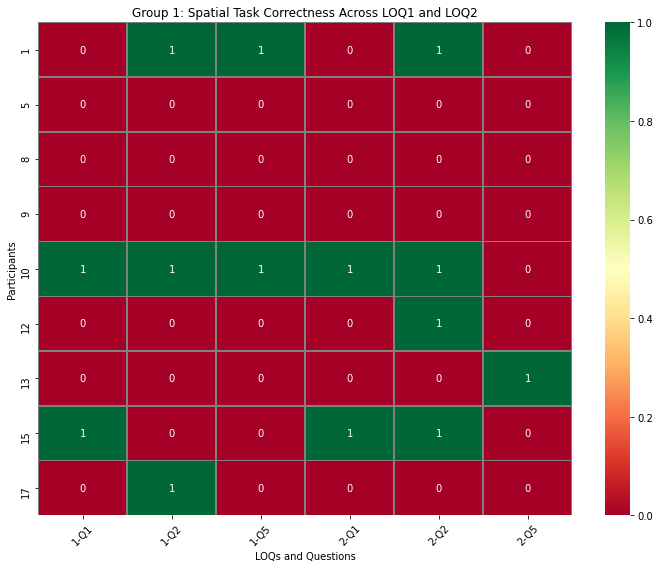

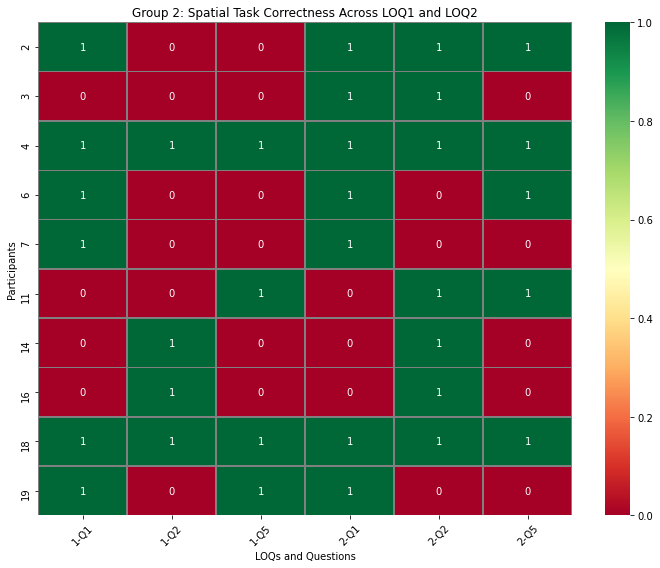

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


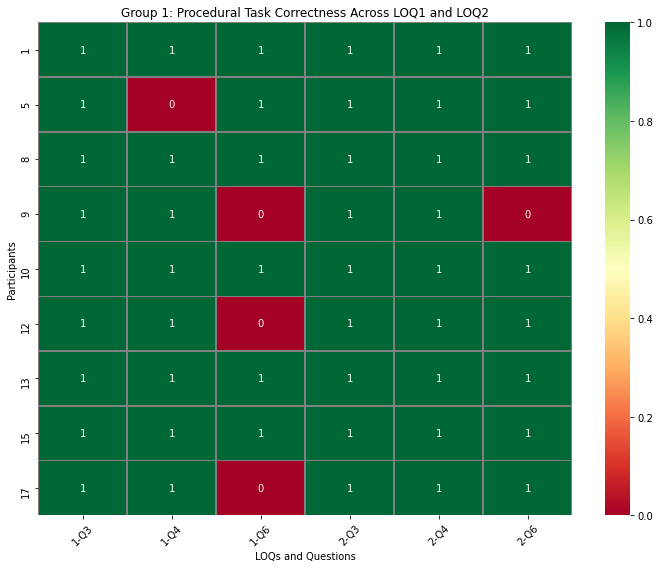

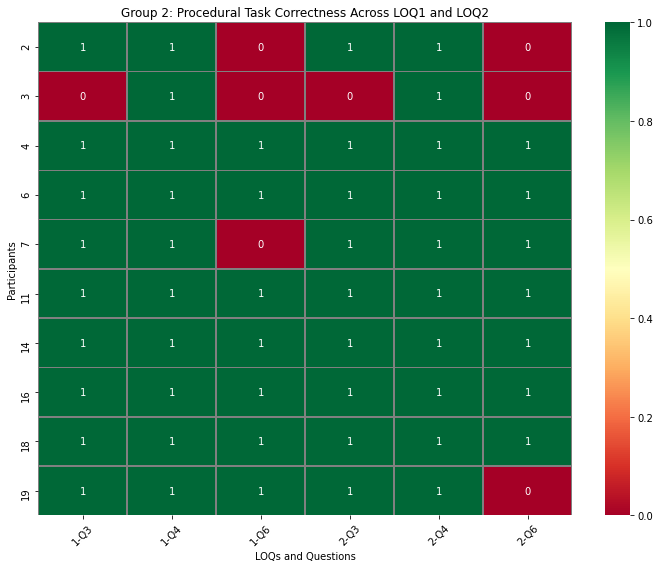

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.sankey import Sankey

# Define spatial and procedural question columns for LOQ1 and LOQ2
spatial_loq1_columns = ['Q1LOQ1', 'Q2LOQ1', 'Q5LOQ1']
spatial_loq2_columns = ['Q1LOQ2', 'Q2LOQ2', 'Q5LOQ2']
procedural_loq1_columns = ['Q3LOQ1', 'Q4LOQ1', 'Q6LOQ1']
procedural_loq2_columns = ['Q3LOQ2', 'Q4LOQ2', 'Q6LOQ2']

# Prepare data for spatial tasks
spatial_data = data[['Group'] + spatial_loq1_columns + spatial_loq2_columns]
spatial_data['Participant'] = spatial_data.index + 1

# Split data for Group 1 and Group 2
group_1_spatial_data = spatial_data[spatial_data['Group'] == 1]
group_2_spatial_data = spatial_data[spatial_data['Group'] == 2]

# Melt and prepare data for easier plotting (Group 1 - Spatial)
melted_group_1_spatial = pd.melt(
    group_1_spatial_data,
    id_vars=['Participant', 'Group'],
    value_vars=spatial_loq1_columns + spatial_loq2_columns,
    var_name='Question_LOQ',
    value_name='Correct'
)
melted_group_1_spatial['Question'] = melted_group_1_spatial['Question_LOQ'].str.extract(r'(Q\d)')
melted_group_1_spatial['LOQ'] = melted_group_1_spatial['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

# Create pivot table for heatmap visualization (Group 1 - Spatial)
group_1_spatial_heatmap_data = melted_group_1_spatial.pivot_table(
    index='Participant',
    columns=['LOQ', 'Question'],
    values='Correct',
    aggfunc='first'
)

# Plot heatmap for Group 1 - Spatial Tasks
plt.figure(figsize=(10, 8))
sns.heatmap(
    group_1_spatial_heatmap_data,
    annot=True,
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)
plt.title('Group 1: Spatial Task Correctness Across LOQ1 and LOQ2')
plt.xlabel('LOQs and Questions')
plt.ylabel('Participants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Repeat for Group 2 - Spatial Tasks
melted_group_2_spatial = pd.melt(
    group_2_spatial_data,
    id_vars=['Participant', 'Group'],
    value_vars=spatial_loq1_columns + spatial_loq2_columns,
    var_name='Question_LOQ',
    value_name='Correct'
)
melted_group_2_spatial['Question'] = melted_group_2_spatial['Question_LOQ'].str.extract(r'(Q\d)')
melted_group_2_spatial['LOQ'] = melted_group_2_spatial['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

group_2_spatial_heatmap_data = melted_group_2_spatial.pivot_table(
    index='Participant',
    columns=['LOQ', 'Question'],
    values='Correct',
    aggfunc='first'
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    group_2_spatial_heatmap_data,
    annot=True,
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)
plt.title('Group 2: Spatial Task Correctness Across LOQ1 and LOQ2')
plt.xlabel('LOQs and Questions')
plt.ylabel('Participants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Repeat the same process for procedural tasks (Group 1 and Group 2)

# Prepare data for procedural tasks
procedural_data = data[['Group'] + procedural_loq1_columns + procedural_loq2_columns]
procedural_data['Participant'] = procedural_data.index + 1

# Split data for Group 1 and Group 2
group_1_procedural_data = procedural_data[procedural_data['Group'] == 1]
group_2_procedural_data = procedural_data[procedural_data['Group'] == 2]

# Melt and prepare data for easier plotting (Group 1 - Procedural)
melted_group_1_procedural = pd.melt(
    group_1_procedural_data,
    id_vars=['Participant', 'Group'],
    value_vars=procedural_loq1_columns + procedural_loq2_columns,
    var_name='Question_LOQ',
    value_name='Correct'
)
melted_group_1_procedural['Question'] = melted_group_1_procedural['Question_LOQ'].str.extract(r'(Q\d)')
melted_group_1_procedural['LOQ'] = melted_group_1_procedural['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

# Create pivot table for heatmap visualization (Group 1 - Procedural)
group_1_procedural_heatmap_data = melted_group_1_procedural.pivot_table(
    index='Participant',
    columns=['LOQ', 'Question'],
    values='Correct',
    aggfunc='first'
)

# Plot heatmap for Group 1 - Procedural Tasks
plt.figure(figsize=(10, 8))
sns.heatmap(
    group_1_procedural_heatmap_data,
    annot=True,
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)
plt.title('Group 1: Procedural Task Correctness Across LOQ1 and LOQ2')
plt.xlabel('LOQs and Questions')
plt.ylabel('Participants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Repeat for Group 2 - Procedural Tasks
melted_group_2_procedural = pd.melt(
    group_2_procedural_data,
    id_vars=['Participant', 'Group'],
    value_vars=procedural_loq1_columns + procedural_loq2_columns,
    var_name='Question_LOQ',
    value_name='Correct'
)
melted_group_2_procedural['Question'] = melted_group_2_procedural['Question_LOQ'].str.extract(r'(Q\d)')
melted_group_2_procedural['LOQ'] = melted_group_2_procedural['Question_LOQ'].str.extract(r'LOQ(\d)').astype(int)

group_2_procedural_heatmap_data = melted_group_2_procedural.pivot_table(
    index='Participant',
    columns=['LOQ', 'Question'],
    values='Correct',
    aggfunc='first'
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    group_2_procedural_heatmap_data,
    annot=True,
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)
plt.title('Group 2: Procedural Task Correctness Across LOQ1 and LOQ2')
plt.xlabel('LOQs and Questions')
plt.ylabel('Participants')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
participant_data = filtered_data[filtered_data['Participant'] == 3]
print(participant_data)

   Group  Participant  Q1Task  Q2Task  Q3Task  Q4Task  Q5Task  Q6tTask
2      2            3       1       1       0       0       1        1


In [11]:
participant_data = filtered_data[filtered_data['Participant'] == 2]
print(participant_data)

   Group  Participant  Q1Task  Q2Task  Q3Task  Q4Task  Q5Task  Q6tTask
1      2            2       1       0       0       0       0        0


Counts of Correct Responses by Group
       Correct_Q1  Correct_Q2  Correct_Q3  Correct_Q4  Correct_Q5  Correct_Q6
Group                                                                        
1               3           5           9           9           3           8
2               7           8           9          10           7           8

Wilcoxon Rank-Sum Test Results (Group 1 vs. Group 2 for Each Question)
    statistic   p_value
Q1  -1.347219  0.177910
Q2  -0.898146  0.369108
Q3   0.367423  0.713303
Q4   0.000000  1.000000
Q5  -1.347219  0.177910
Q6   0.326599  0.743971


/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

ValueError: All numbers are identical in kruskal